# Results

## Setup

In [1]:
# Setup

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.base import clone
import joblib

## Load Data

In [2]:
# load the clean datasets
df_train = pd.read_csv("data_train.csv")
df_test = pd.read_csv("data_test.csv")

## Configuration

In [3]:
features = [
    "employment_mix_ranked",
    "employment_residential_mix_ranked",
    "intersection_density_ranked",
    "transit_accessibility_ranked",
]

outcomes = [
    "high_cholesterol_prevalence",
    "depression_prevalence",
    "high_blood_pressure_prevalence",
    "obesity_prevalence",
    "cancer_prevalence",
]

## Fitting and plotting

We fit our Pipeline (imputer + RandomForestRegressor with the parameters appearing most often in our cross validation) on our training set for each of our outcomes. For each outcome:
- we plot the predictions $\hat{y}$ versus the obervation $y$ and save the plots (deviation from the line $y = x$ means poor fit),
- we plot the residuals $y - \hat{y}$ versus the prediction $\hat{y}$ and save the plots (deviation from $x = 0$ means poor fit), 
- we determine the two most important features,
- we plot the PDP (Partial Dependence Plot) for each of the most important feature and save them
- we summarize our results in a dataframe title **summary**.

[high_cholesterol_prevalence]  Train RMSE=4.044, R²=0.265 | Test RMSE=4.368, R^2=0.205 | Dummy Test RMSE=5.024


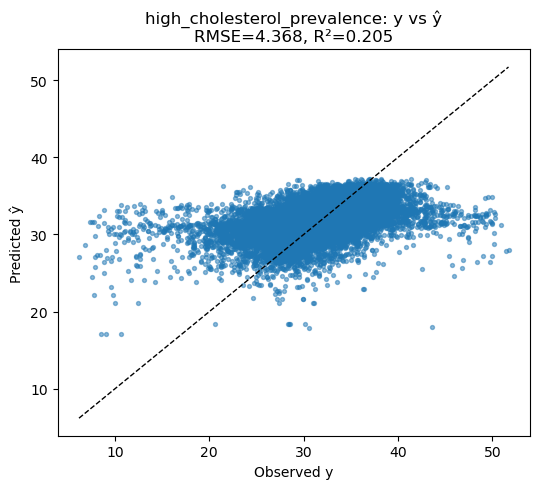

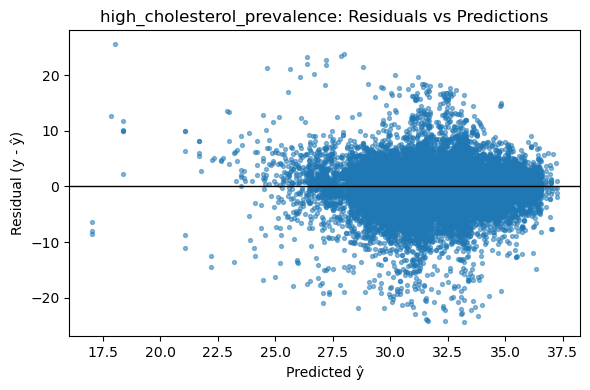

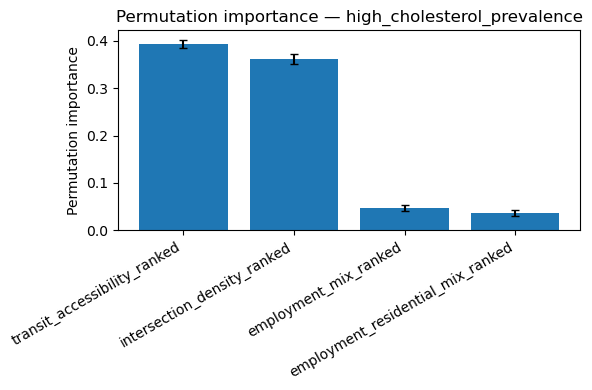

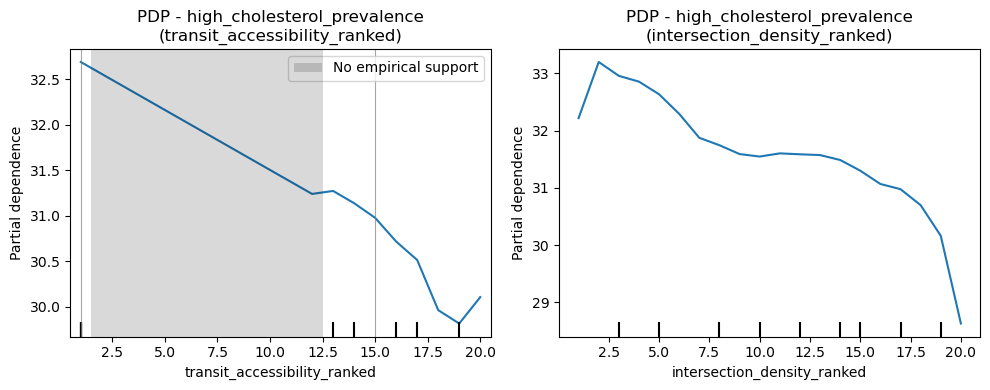

[depression_prevalence]  Train RMSE=3.085, R²=0.178 | Test RMSE=3.947, R^2=0.049 | Dummy Test RMSE=4.382


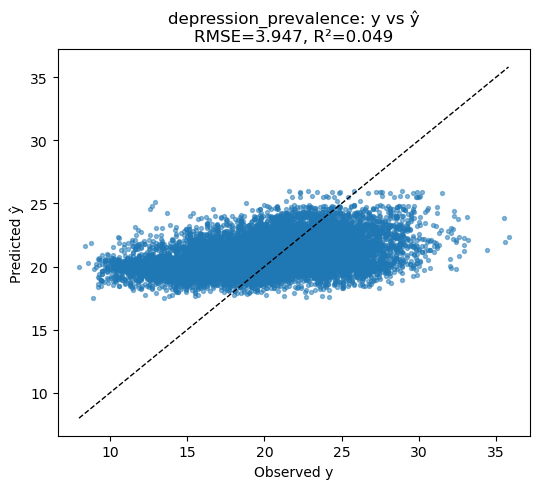

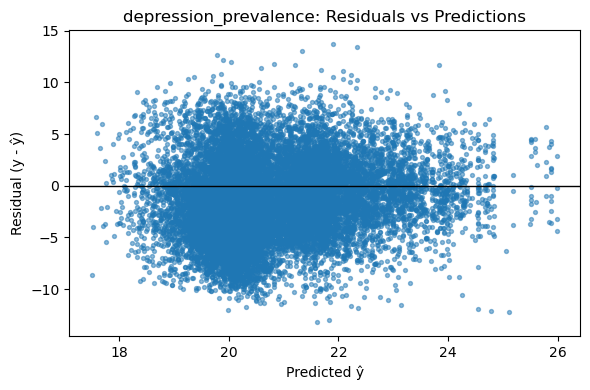

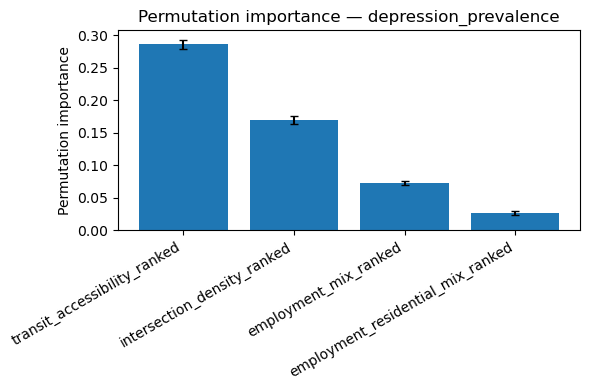

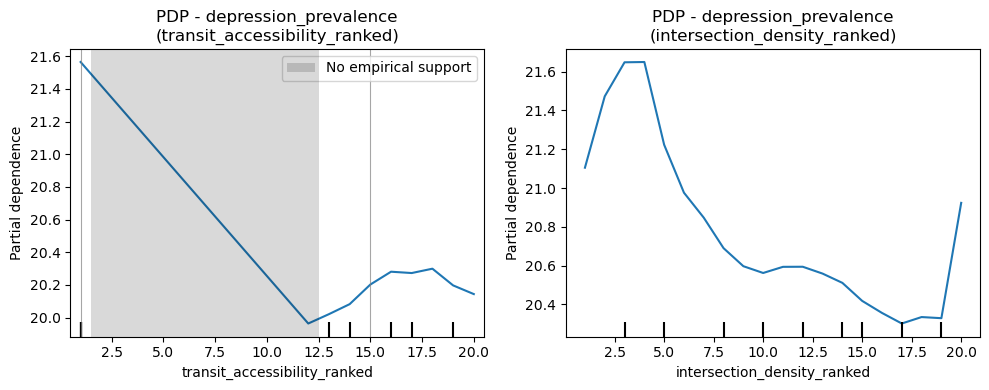

[high_blood_pressure_prevalence]  Train RMSE=6.557, R²=0.203 | Test RMSE=6.695, R^2=0.129 | Dummy Test RMSE=7.452


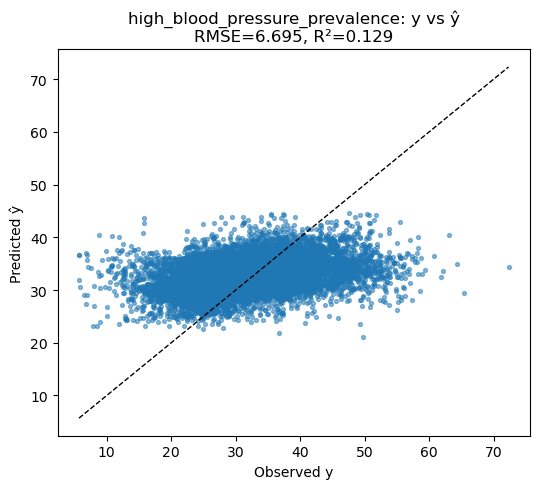

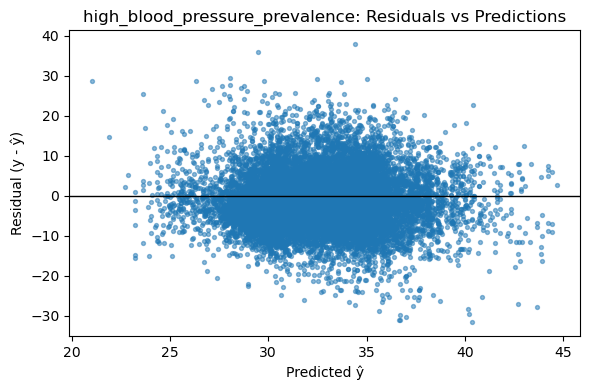

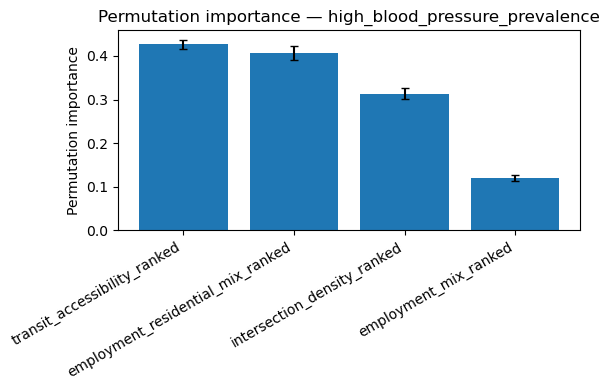

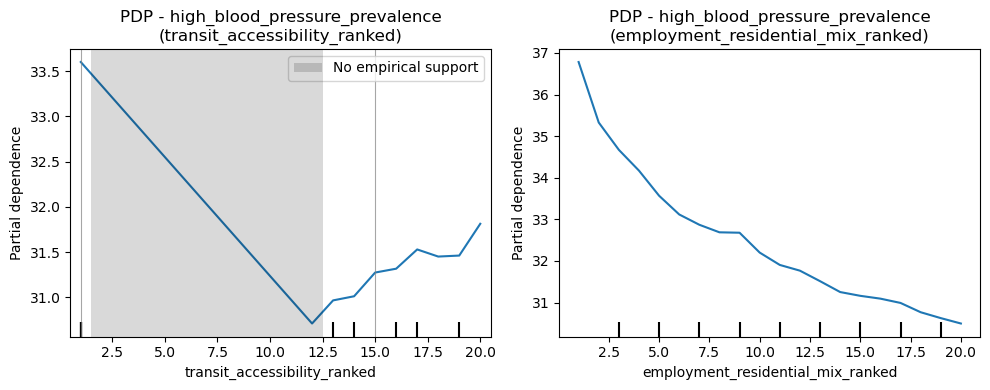

[obesity_prevalence]  Train RMSE=5.808, R²=0.243 | Test RMSE=6.554, R^2=0.115 | Dummy Test RMSE=7.310


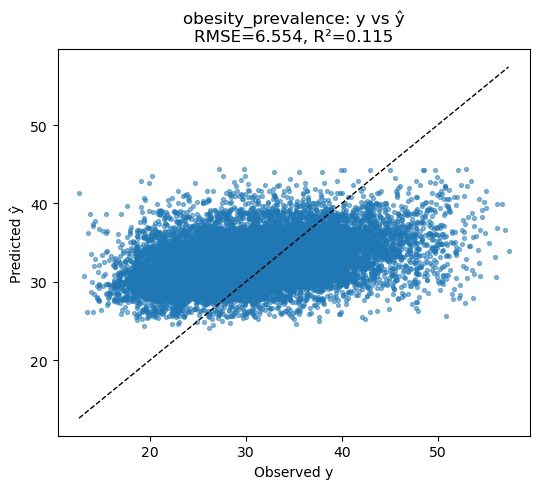

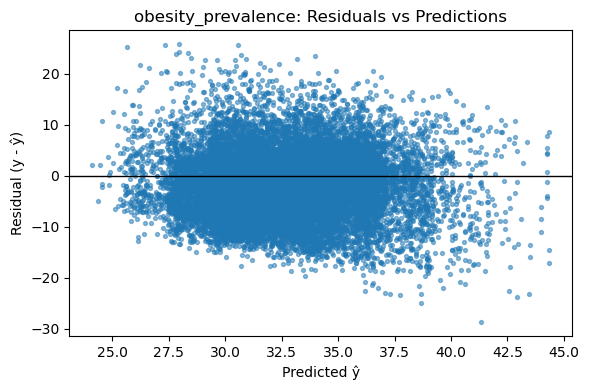

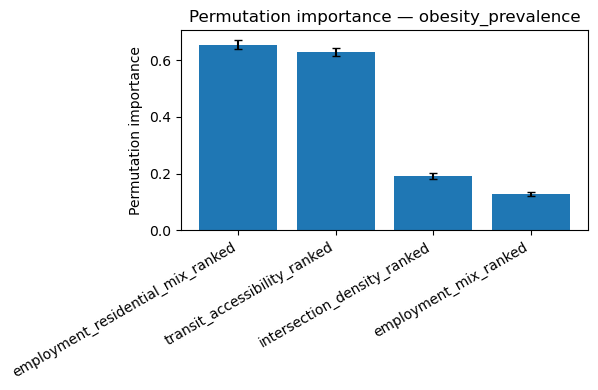

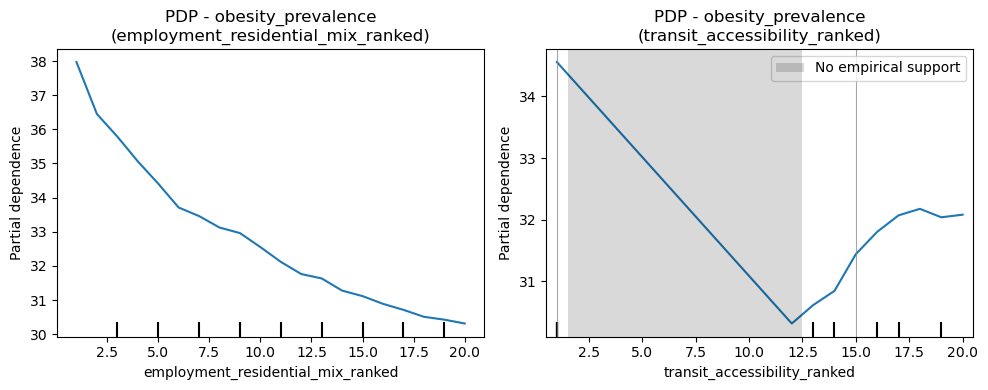

[cancer_prevalence]  Train RMSE=1.635, R²=0.233 | Test RMSE=1.936, R^2=0.169 | Dummy Test RMSE=2.137


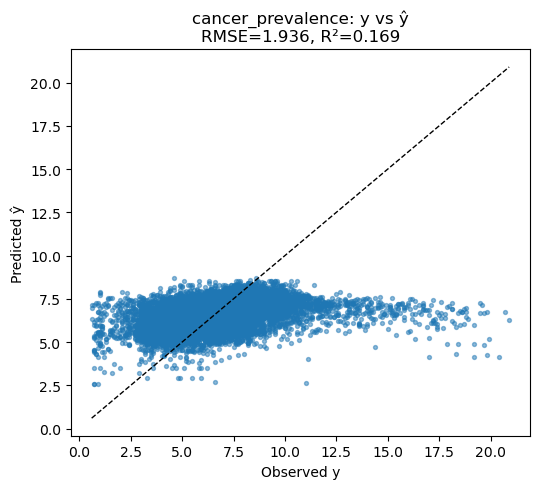

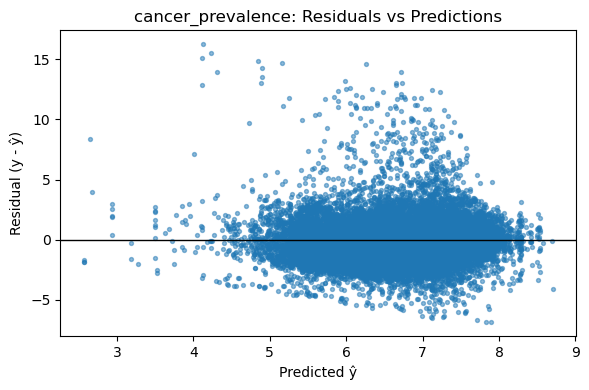

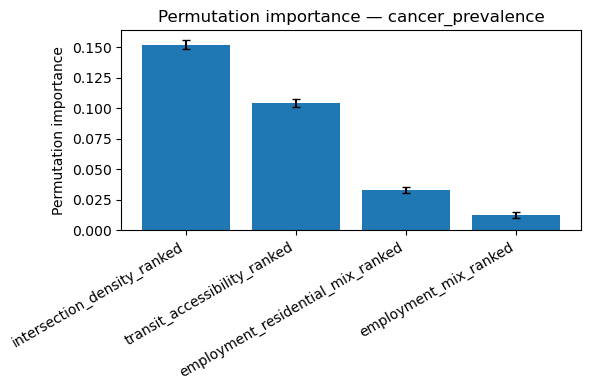

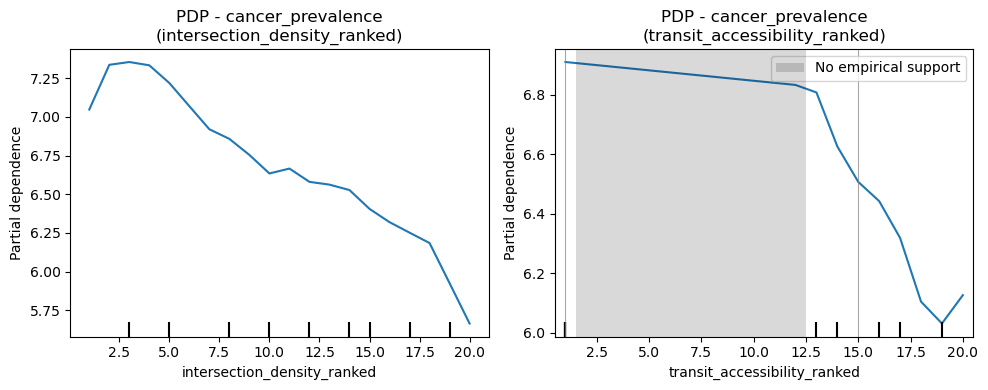

,target,rmse_train,r2_train,rmse_test,r2_test,rmse_test_dummy,best_params
0,cancer_prevalence,1.635,0.233,1.936,0.169,2.137,"{'n_estimators': 300, 'max_depth': 10, 'min_sa..."
1,depression_prevalence,3.085,0.178,3.947,0.049,4.382,"{'n_estimators': 300, 'max_depth': 10, 'min_sa..."
2,high_cholesterol_prevalence,4.044,0.265,4.368,0.205,5.024,"{'n_estimators': 300, 'max_depth': 10, 'min_sa..."
3,obesity_prevalence,5.808,0.243,6.554,0.115,7.310,"{'n_estimators': 300, 'max_depth': 10, 'min_sa..."
4,high_blood_pressure_prevalence,6.557,0.203,6.695,0.129,7.452,"{'n_estimators': 300, 'max_depth': 10, 'min_sa..."


In [4]:
# We chose the RF best params appearing most often in our model evaluation
best_params = dict(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    min_samples_split=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)

# We instantiate our model
pipe_rf = Pipeline(
    [
        ("imp", SimpleImputer(strategy="median")),
        ("rf", RandomForestRegressor(**best_params)),
    ]
)

# We create the final_artifacts directory within our folder result (if it does not exist yet)
os.makedirs("final_artifacts", exist_ok=True)


# We create a small helper function to get the RMSE from oberved y and predicted \hat{y}
def rmse(y, yhat):
    return float(np.sqrt(mean_squared_error(y, yhat)))


# We create an empty summary_rows which we will append in our for loop to add our results
summary_rows = []

# We loop over all possible outcomes
for target in outcomes:

    cols_needed = features + [target]
    tr = df_train.dropna(subset=cols_needed).copy()
    te = df_test.dropna(subset=cols_needed).copy()

    X_train = tr[features].to_numpy(float)
    y_train = tr[target].to_numpy(float)
    X_test = te[features].to_numpy(float)
    y_test = te[target].to_numpy(float)

    # We create a subfolder of final_artifacts for our target (if it does not exist yet)
    out_dir = f"final_artifacts/{target}"
    os.makedirs(out_dir, exist_ok=True)

    # Dummy baseline (fit on train, predict test)
    dummy = DummyRegressor(strategy="mean")
    dummy.fit(X_train, y_train)
    yhat_test_dummy = dummy.predict(X_test)
    rmse_test_dummy = rmse(y_test, yhat_test_dummy)

    # Fit RF on train
    pipe_rf.fit(X_train, y_train)

    # Predictions & metrics
    yhat_train = pipe_rf.predict(X_train)
    yhat_test = pipe_rf.predict(X_test)

    rmse_train = rmse(y_train, yhat_train)
    r2_train = float(r2_score(y_train, yhat_train))
    rmse_test = rmse(y_test, yhat_test)
    r2_test = float(r2_score(y_test, yhat_test))

    print(
        f"[{target}]  Train RMSE={rmse_train:.3f}, R²={r2_train:.3f} | "
        f"Test RMSE={rmse_test:.3f}, R^2={r2_test:.3f} | Dummy Test RMSE={rmse_test_dummy:.3f}"
    )

    # We plot and save y vs \hat{y}
    def plot_y_vs_yhat(y_true, y_hat, title, path):
        plt.figure(figsize=(5.5, 5))
        plt.scatter(y_true, y_hat, s=8, alpha=0.5)
        lo = min(float(np.min(y_true)), float(np.min(y_hat)))
        hi = max(float(np.max(y_true)), float(np.max(y_hat)))
        plt.plot([lo, hi], [lo, hi], "k--", lw=1)  # 45 degree line
        RMSE = rmse(y_true, y_hat)
        R2 = float(r2_score(y_true, y_hat))
        plt.xlabel("Observed y")
        plt.ylabel("Predicted ŷ")
        plt.title(f"{title}\nRMSE={RMSE:.3f}, R²={R2:.3f}")
        plt.tight_layout()
        plt.savefig(path, dpi=150, bbox_inches="tight")
        plt.show()

    plot_y_vs_yhat(
        y_test,
        yhat_test,
        f"{target}: y vs ŷ",
        f"{out_dir}/scatter_test_{target}.png",
    )

    # We plot and save residuals vs predictions
    resid_test = y_test - yhat_test
    plt.figure(figsize=(6, 4))
    plt.scatter(yhat_test, resid_test, s=8, alpha=0.5)
    plt.axhline(0, color="k", lw=1)
    plt.xlabel("Predicted ŷ")
    plt.ylabel("Residual (y - ŷ)")
    plt.title(f"{target}: Residuals vs Predictions")
    plt.tight_layout()
    plt.savefig(
        f"{out_dir}/residuals_vs_pred_test_{target}.png", dpi=150, bbox_inches="tight"
    )
    plt.show()

    # We save predictions & metrics
    preds_train = pd.DataFrame(
        {
            "set": "train",
            "y_true": y_train,
            "y_pred": yhat_train,
            "residual": y_train - yhat_train,
        }
    )
    preds_test = pd.DataFrame(
        {
            "set": "test",
            "y_true": y_test,
            "y_pred": yhat_test,
            "residual": y_test - yhat_test,
        }
    )
    pd.concat([preds_train, preds_test]).to_csv(
        f"{out_dir}/predictions.csv", index=False
    )

    pd.DataFrame(
        [
            {
                "target": target,
                "rmse_train": rmse_train,
                "r2_train": r2_train,
                "rmse_test": rmse_test,
                "r2_test": r2_test,
                "rmse_test_dummy": rmse_test_dummy,
                "n_train": len(y_train),
                "n_test": len(y_test),
            }
        ]
    ).to_csv(f"{out_dir}/metrics.csv", index=False)

    # Permutation importance on TEST (to avoid leakage):
    # We measure how much the model's test error increases when we randomly shuffle
    # (permute) one feature at a time. If shuffling a feature hurts performance a lot,
    # that feature was important to the model's predictions.
    r = permutation_importance(
        pipe_rf,  # fitted model
        X_test,  # evaluate on the TEST set
        y_test,
        n_repeats=30,  # repeat the shuffle 30 times for stability
        random_state=42,  # reproducibility across runs
        n_jobs=-1,  # parallelize across CPUs
        scoring="neg_root_mean_squared_error",  # RMSE_perm - RMSE_base
    )

    # Build a tidy table: mean importance and its std-dev across repeats
    imp = pd.DataFrame(
        {
            "feature": features,
            "perm_importance": r.importances_mean,  # mean RMSE_perm - RMSE_base (positive = worse when shuffled)
            "sd": r.importances_std,  # variability across the n_repeats shuffles
        }
    ).sort_values("perm_importance", ascending=False)

    # Save the table for the report/notebook
    imp.to_csv(f"{out_dir}/perm_importance_test.csv", index=False)

    # --- Plotting the importances ---
    plt.figure(figsize=(6, 4))

    order = np.argsort(imp["perm_importance"].values)[
        ::-1
    ]  # Order features from most to least important

    # Bar chart with error bars (\pm one std) from the repeats
    plt.bar(
        np.arange(len(features)),  # x positions: 0,1,2,... for each feature
        imp["perm_importance"].values[order],  # bar heights (mean importance)
        yerr=imp["sd"].values[order],  # error bar size (\pm 1 std across repeats)
        capsize=3,  # little horizontal caps on error bars
    )

    plt.xticks(
        np.arange(len(features)),  # tick positions must match the bar positions
        imp["feature"].values[order],  # the text labels shown under each bar
        rotation=30,
        ha="right",  # rotate and right-align for readability
    )

    plt.ylabel(
        "Permutation importance"
    )  # y-axis label; bigger bar implies bigger RMSE increase when shuffled
    plt.title(f"Permutation importance — {target}")  # figure title with outcome name
    plt.tight_layout()  # prevent label/title clipping
    plt.savefig(
        f"{out_dir}/perm_importance_test.png", dpi=150, bbox_inches="tight"
    )  # save to file
    plt.show()  # render in notebook

    # --- PDPs for the top 2 features (on test) with shaded gap for transit ---

    top_feats = imp["feature"].head(2).tolist()  # top 2 features
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # two subplots side-by-side

    for ax, f in zip(axes, top_feats):
        # column index of feature f in X_test (Recall X_test = te[features])
        j = features.index(f)

        # Draw the PDP for feature j. We capture the returned display.
        disp = PartialDependenceDisplay.from_estimator(
            pipe_rf,
            X_test,
            [j],                 # list with a single feature index
            feature_names=features,
            ax=ax,
            kind="average",      # standard PDP (average over other features)
            centered=False,      # plot raw PD curve, not centered at mean
        )

        # PartialDependenceDisplay can create/replace axes, so we recover the axis it actually used.
        # disp.axes_ is either:
        #   - a single Axes object, or
        #   - a 2D array like [[ax_obj]]
        if hasattr(disp, "axes_"):
            if np.ndim(disp.axes_) == 0:
                ax_used = disp.axes_
            elif np.ndim(disp.axes_) == 1:
                # sometimes it's a 1D array-like
                ax_used = disp.axes_[0]
            else:
                # often it's shape (1,1)
                ax_used = disp.axes_[0, 0]
        else:
            # fallback: assume it actually drew on `ax`
            ax_used = ax

        # Set the title on the actual axis
        ax_used.set_title(f"PDP - {target}\n({f})")

        # Special shading for the transit rank gap (no empirical support in 1.5–12.5)
        if f == "transit_accessibility_ranked":
            # Force x-limits to show full rank range
            ax_used.set_xlim(0.5, 20.5)

            # Shade region [1.5, 12.5] = ranks where we have no observed tracts
            ax_used.axvspan(
                1.5,
                12.5,
                facecolor="black",
                alpha=0.15,
                zorder=10,
                label="No empirical support",
            )

            # Guide lines where the real data actually live
            ax_used.axvline(1,  color="gray", lw=0.8, alpha=0.7)
            ax_used.axvline(15, color="gray", lw=0.8, alpha=0.7)

            # Add legend once we've added the shaded patch
            ax_used.legend(loc="best")

    plt.tight_layout()
    plt.savefig(f"{out_dir}/pdp_top_features.png", dpi=150, bbox_inches="tight")
    plt.show()


    # --- Save the trained model for this outcome ---
    joblib.dump(pipe_rf, f"{out_dir}/rf_model.joblib")

    # --- Append to summary ---
    summary_rows.append(
        {
            "target": target,
            "rmse_train": round(rmse_train, 3),
            "r2_train": round(r2_train, 3),
            "rmse_test": round(rmse_test, 3),
            "r2_test": round(r2_test, 3),
            "rmse_test_dummy": round(rmse_test_dummy, 3),
            "best_params": best_params,
        }
    )

# --- Final summary across outcomes ---
summary = pd.DataFrame(summary_rows).sort_values("rmse_test").reset_index(drop=True)
summary.to_csv("final_artifacts/summary_rf_all_outcomes.csv", index=False)
summary

We grayed out the zone between 1.5 and 12.5 in the case where the feature with most importance is `transit_accessibility_ranked` since no such values are avalable by construction.

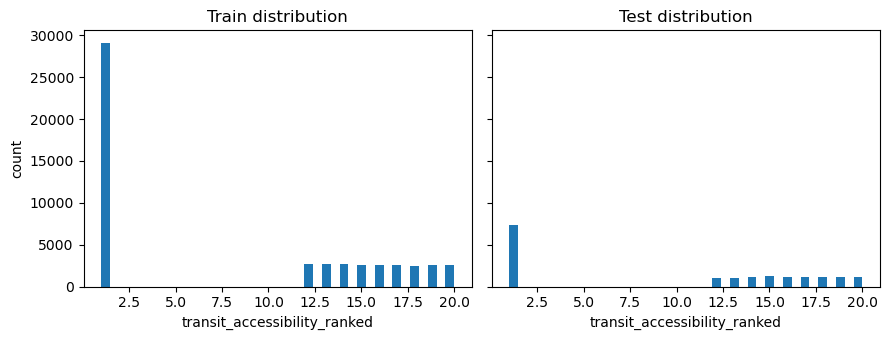

In [5]:
fig, ax = plt.subplots(1,2, figsize=(9,3.5), sharey=True)
ax[0].hist(df_train["transit_accessibility_ranked"].dropna(), bins=40)
ax[0].set_title("Train distribution")
ax[1].hist(df_test["transit_accessibility_ranked"].dropna(), bins=40)
ax[1].set_title("Test distribution")
for a in ax: a.set_xlabel("transit_accessibility_ranked")
ax[0].set_ylabel("count")
plt.tight_layout(); plt.show()

## Summary histograms

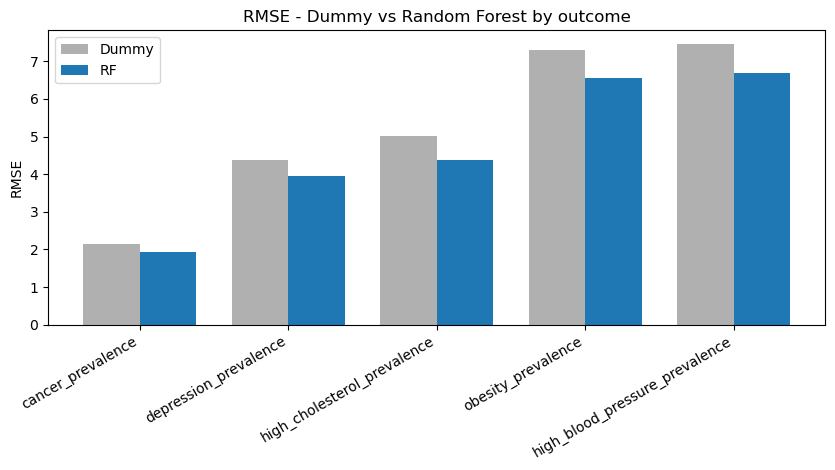

Saved: final_artifacts/plots/rmse_dummy_vs_rf.png


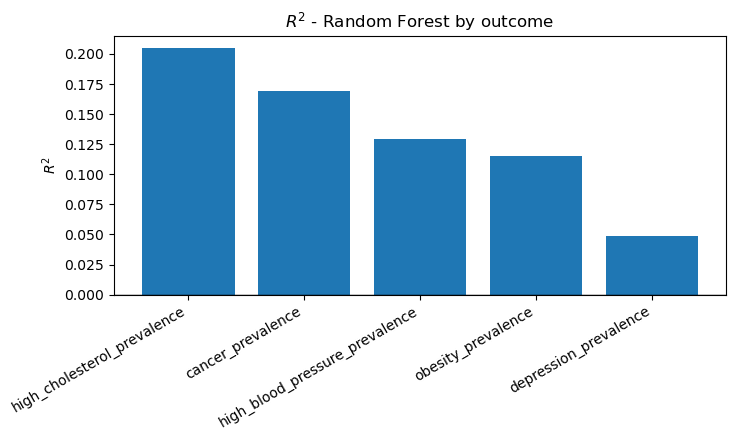

Saved: final_artifacts/plots/rf_test_r2_by_outcome.png


In [12]:
# Save folder
PLOTS_DIR = "final_artifacts/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# --- fig1: Dummy vs RF Test RMSE (grouped bars) ---
df_cmp = summary.sort_values("rmse_test", ascending=True)[
    ["target", "rmse_test", "rmse_test_dummy"]
].copy()

x = np.arange(len(df_cmp))
w = 0.38

plt.figure(figsize=(8.5, 4.8))
plt.bar(x - w / 2, df_cmp["rmse_test_dummy"], width=w, label="Dummy", color="#B0B0B0")
plt.bar(x + w / 2, df_cmp["rmse_test"], width=w, label="RF")
plt.xticks(x, df_cmp["target"], rotation=30, ha="right")
plt.ylabel("RMSE")
plt.title("RMSE - Dummy vs Random Forest by outcome")
plt.legend()
plt.tight_layout()
fig1_path = f"{PLOTS_DIR}/rmse_dummy_vs_rf.png"
plt.savefig(fig1_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", fig1_path)

# --- fig2: Test R^2 by outcome (vertical bars) ---
df_r2 = summary.sort_values("r2_test", ascending=False).copy()

plt.figure(figsize=(7.5, 4.5))
plt.bar(df_r2["target"], df_r2["r2_test"])
plt.axhline(0, color="k", linewidth=1)
plt.xticks(rotation=30, ha="right")
plt.ylabel("$R^2$")
plt.title("$R^2$ - Random Forest by outcome")
plt.tight_layout()
fig2_path = f"{PLOTS_DIR}/rf_test_r2_by_outcome.png"
plt.savefig(fig2_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", fig2_path)

## Bootstrap PDP Confidence Intervals

We manually create confidence intervals for our PDP via a bootstrapping method. Since the program is long to run, we only apply to the outcome for which we had the best $R^2$ score, i.e., `high_cholesterol_prevalence`, and for the two feature with the most importance, i.e. `transit_accessibility_ranked` and `intersection_density_ranked`.

### Definining the PDP bootstrap

In [7]:
def pd_curve_on_grid(model, X, j, grid):
    """
    Compute a 1D Partial Dependence (PD) curve for feature j on a chosen grid.

    Parameters:
    - model : fitted model.
    - X : array-like, shape (n_samples, n_features), the dataset over which to average the dependence.
    - j : int, column index of the feature to analyze.
    - grid : array-like, shape (G,), values of the j-th feature at which to evaluate the PD curve.

    Returns:
    means : np.ndarray, shape (G,), the average predictions at each grid value (the PD curve).

    Math:
    PD_j(v) ≈ (1/n) * sum_{i=1..n}  \hat{f}( v, x_{-j}^{(i)} )
    """
    # Ensure we have a NumPy array view of X (won't modify caller's data)
    X = np.asarray(X)

    # Prepare output: one mean prediction per grid value
    means = np.empty(len(grid), dtype=float)

    # Loop over grid values v
    for t, v in enumerate(grid):
        # Make a copy so we don't overwrite the original X
        Xv = X.copy()

        # Set the j-th feature to v for all rows (holding others fixed)
        # This constructs the counterfactual batch (v, x_{-j}^{(i)})
        Xv[:, j] = v

        # Predict on this counterfactual batch, then average across rows
        means[t] = model.predict(Xv).mean()

    # Return the PD curve sampled on 'grid'
    return means

<>:15: SyntaxWarning: invalid escape sequence '\h'
<>:15: SyntaxWarning: invalid escape sequence '\h'
/var/folders/wl/6mlcq2bj3_z6kxrhbdrjs84h0000gn/T/ipykernel_83774/3626534436.py:15: SyntaxWarning: invalid escape sequence '\h'
  PD_j(v) ≈ (1/n) * sum_{i=1..n}  \hat{f}( v, x_{-j}^{(i)} )


In [8]:
def pd_bootstrap_band_refit(
    pipe_template,  # unfitted model with our hyperparams
    X_train,
    y_train,
    X_test,
    j,  # integer column index of the feature to analyze
    grid,  # 1D array of values of shape (G,) at which to evaluate the PD curve
    B=150,  # number of bootstrap refits
    alpha=0.05,  # 1 - alpha central band (e.g., 0.05 to get 95% confidence interval)
    frac_train=0.7,  # m-out-of-n fraction for train resampling
    frac_test=0.7,  # m-out-of-n fraction for test resampling (for PD averaging)
    random_state=42,
):
    """
    Returns:
    - grid : (G,) array, (echoed back)
    - mean : (G,) array, pointwise mean PD across bootstrap refits
    - lo   : (G,) array, pointwise lower percentile (alpha/2)
    - hi   : (G,) array, pointwise upper percentile (1 - alpha/2)

    Math:
    For b = 1..B:
      1) Sample frac_train * n_train rows WITH replacement from (X_train, y_train).
      2) Fit a fresh clone of pipe_template on this bootstrap sample.
      3) Sample frac_test * n_test rows WITH replacement from X_test.
      4) Compute the PD curve on 'grid' by averaging predictions over that sampled X_test.
      5) Aggregate curves to get mean and percentile band.
    """
    rng = np.random.default_rng(random_state)

    X_train = np.asarray(X_train, float)
    y_train = np.asarray(y_train, float)
    X_test = np.asarray(X_test, float)
    grid = np.asarray(grid, float)

    n_tr = len(X_train)
    n_te = len(X_test)

    # Simple row-resampling helper (no groups)
    def _resample_rows(n, frac):
        m = max(2, int(frac * n))
        return rng.integers(0, n, size=m)  # with replacement

    curves = []  # will be (B, G)

    for _ in range(B):
        # 1) Bootstrap TRAIN
        idx_tr = _resample_rows(n_tr, frac_train)
        X_tr_b = X_train[idx_tr]
        y_tr_b = y_train[idx_tr]

        # 2) Fit fresh clone
        est = clone(pipe_template)
        est.fit(X_tr_b, y_tr_b)

        # 3) Bootstrap TEST subset (for PD averaging)
        idx_te = _resample_rows(n_te, frac_test)
        X_te_b = X_test[idx_te]

        # 4) PD curve on this draw
        curves.append(pd_curve_on_grid(est, X_te_b, j, grid))

    curves = np.vstack(curves)  # shape (B, G)
    mean = curves.mean(axis=0)  # mean PD curve over bootstraps
    lo = np.percentile(curves, 100 * alpha / 2, axis=0)  # Pointwise lower percentile
    hi = np.percentile(
        curves, 100 * (1 - alpha / 2), axis=0
    )  # Pointwise upper percentile

    return grid, mean, lo, hi

### high_cholesterol_prevalence vs transit_accessibility_ranked

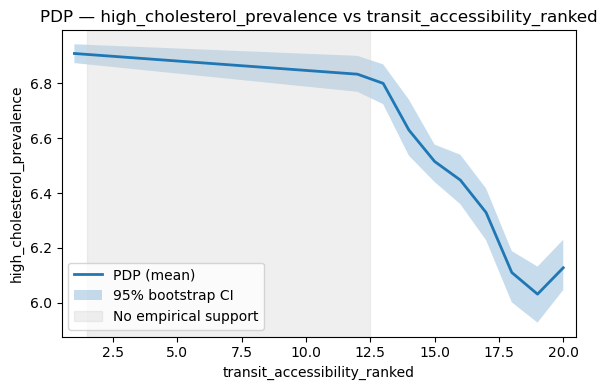

In [9]:
pipe_rf_template = clone(pipe_rf)

# Choose feature
feat = "transit_accessibility_ranked"
target = "high_cholesterol_prevalence"
j = features.index(feat)

# Use observed support for gappy ranks (cleanest)
grid = np.sort(np.unique(X_test[:, j]).astype(float))

# We apply our pd_bootstrap_band_refit function
grid, mean, lo, hi = pd_bootstrap_band_refit(
    pipe_template=pipe_rf_template,  # unfitted template (NOT the already-fitted pipe)
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    j=j,
    grid=grid,
    B=120,  # bump to 200+ if you have time
    alpha=0.05,  # 10–90% band; use 0.05 for 95%
    frac_train=0.7,  # 70% m-out-of-n bootstrap on train
    frac_test=0.7,  # 70% m-out-of-n bootstrap on test
)

plt.figure(figsize=(6, 4))
plt.plot(grid, mean, lw=2, label="PDP (mean)")
plt.fill_between(grid, lo, hi, alpha=0.25, label="95% bootstrap CI")

# Optional: shade unsupported ranks if you ever use a dense grid
if feat == "transit_accessibility_ranked":
    plt.xlim(0.5, 20.5)
    plt.axvspan(1.5, 12.5, color="lightgray", alpha=0.35, label="No empirical support")

plt.xlabel(feat)
plt.ylabel(target)
plt.title(f"PDP — {target} vs {feat}")
plt.legend()
plt.tight_layout()
plt.savefig(f"{out_dir}/pdp_bootstrap_refit_{feat}.png", dpi=150, bbox_inches="tight")
plt.show()

### high_cholesterol_prevalence vs intersection_density_ranked

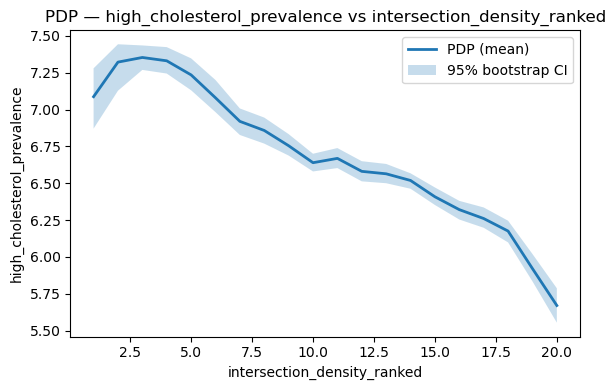

In [10]:
pipe_rf_template = clone(pipe_rf)

# Choose feature
feat = "intersection_density_ranked"
target = "high_cholesterol_prevalence"
j = features.index(feat)

# Use observed support for gappy ranks (cleanest)
grid = np.sort(np.unique(X_test[:, j]).astype(float))

# We apply our pd_bootstrap_band_refit function
grid, mean, lo, hi = pd_bootstrap_band_refit(
    pipe_template=pipe_rf_template,  # unfitted template (NOT the already-fitted pipe)
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    j=j,
    grid=grid,
    B=120,  # bump to 200+ if you have time
    alpha=0.05,  # 10–90% band; use 0.05 for 95%
    frac_train=0.7,  # 70% m-out-of-n bootstrap on train
    frac_test=0.7,  # 70% m-out-of-n bootstrap on test
)

plt.figure(figsize=(6, 4))
plt.plot(grid, mean, lw=2, label="PDP (mean)")
plt.fill_between(grid, lo, hi, alpha=0.25, label="95% bootstrap CI")

# Optional: shade unsupported ranks if you ever use a dense grid
if feat == "transit_accessibility_ranked":
    plt.xlim(0.5, 20.5)
    plt.axvspan(1.5, 12.5, color="lightgray", alpha=0.35, label="No empirical support")

plt.xlabel(feat)
plt.ylabel(target)
plt.title(f"PDP — {target} vs {feat}")
plt.legend()
plt.tight_layout()
plt.savefig(f"{out_dir}/pdp_bootstrap_refit_{feat}.png", dpi=150, bbox_inches="tight")
plt.show()